## Notebook summary

| Item | Details |
| --- | --- |
| Purpose | DenseNet-121 Laterality and Paper-Inspired Augmentation Ablation |
| Model / workflow | DenseNet-121/201 |
| Input | not reported |
| Loss | Cross-Entropy (CE) |
| Training / pipeline | Native-CAM experiment |
| Result | "augmentation": "paper_inspired_mild_affine"; canonical_baseline / epoch 01 / warmup / QWK=0.2846 / F1=0.2906 / G1R=0.1699 / AP=0.3204 / selection=0.3022; canonical_baseline / epoch 02 / warmup / QWK=0.3713 / F1=0.2960 / G1R=0.2092 / AP=0.3624 / selection=0... |


# DenseNet-121 Laterality and Paper-Inspired Augmentation Ablation

This controlled experiment tests whether the KL classifier should learn left/right
invariance from augmentation instead of receiving deterministically mirrored right
knees. All arms use the same image split, native-CAM DenseNet-121, cross-entropy
loss, inverse-frequency sampler, staged optimization, seed, and validation selector.

The local paper `docs/paper/fmed-12-1707588.md` used horizontal flips, rotations up
to 30 degrees, 10% shifts, 0.8-1.2 scaling, and shear up to 20 degrees. This notebook
tests the same augmentation families with deliberately smaller geometry because KL
grading depends on subtle joint-space width and alignment:

- `canonical_baseline`: mirror right knees, no random horizontal flip, current mild
  augmentation.
- `natural_flip`: retain natural laterality and use horizontal flip with probability
  0.5; otherwise retain the current mild augmentation.
- `natural_flip_mild_affine`: retain natural laterality, use horizontal flip, and use
  a conservative affine transform (7 degrees, 3% shift, 0.95-1.05 scale, 3 degrees
  shear).

Each arm is selected only on validation data and receives the same native-CAM audit.
The test split is evaluated once, for the best non-canonical arm. Running this
notebook does not alter the existing production checkpoint.


## Execution

Run every cell from top to bottom in one Colab runtime. The notebook writes each arm
to a unique timestamped directory, then writes a comparison table, validation CAM
audit, selected non-canonical checkpoint, and one final test evaluation.


In [ ]:
import csv
import gc
import hashlib
import json
import os
import random
import subprocess
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
import tqdm
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    precision_recall_fscore_support,
    recall_score,
    roc_auc_score,
)
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler

try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    print("Not running in Colab; Drive mount skipped.")

try:
    import timm
except ImportError:
    subprocess.run(["pip", "install", "-q", "timm"], check=True)
    import timm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

dataset_zip = Path("/content/drive/MyDrive/Datasets/kaggle_knee_osteoarthritis.zip")
if dataset_zip.exists():
    subprocess.run(
        ["unzip", "-q", "-o", str(dataset_zip), "-d", "/content/Datasets"],
        check=True,
    )

DATASET_ROOT = Path("/content/Datasets/kaggle_knee_osteoarthritis")
RUN_TIMESTAMP = datetime.now(timezone.utc).strftime(
    "%Y-%m-%d_%H-%M-%S_%f_UTC"
)
RUN_DIR = Path("/content/drive/MyDrive/Models/densenet121_checkpoints") / f"{RUN_TIMESTAMP}_orientation_augmentation_ablation"
RUN_DIR.mkdir(parents=True, exist_ok=False)
print(f"Run directory: {RUN_DIR}")


Mounted at /content/drive
Device: cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
Run directory: /content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-25_00-34-38_777810_UTC_orientation_augmentation_ablation


## Data Preparation and Fixed Arms

Split membership and duplicate filtering are computed once. Laterality handling is
an explicit dataset option, while random geometric augmentation belongs only to the
training transform. Validation and test transforms never use random augmentation.


In [ ]:
class SquarePad:
    def __call__(self, image):
        height, width = image.shape[:2]
        side = max(height, width)
        top = (side - height) // 2
        bottom = side - height - top
        left = (side - width) // 2
        right = side - width - left
        return cv2.copyMakeBorder(
            image, top, bottom, left, right,
            cv2.BORDER_CONSTANT, value=[0, 0, 0],
        )


class CLAHE:
    def __call__(self, image):
        lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
        lightness, channel_a, channel_b = cv2.split(lab)
        lightness = cv2.createCLAHE(
            clipLimit=2.0, tileGridSize=(8, 8)
        ).apply(lightness)
        return cv2.cvtColor(
            cv2.merge((lightness, channel_a, channel_b)),
            cv2.COLOR_LAB2RGB,
        )


ARM_SPECS = [
    {
        "name": "canonical_baseline",
        "canonicalize_laterality": True,
        "horizontal_flip_probability": 0.0,
        "augmentation": "current_mild_rotation",
    },
    {
        "name": "natural_flip",
        "canonicalize_laterality": False,
        "horizontal_flip_probability": 0.5,
        "augmentation": "current_mild_rotation",
    },
    {
        "name": "natural_flip_mild_affine",
        "canonicalize_laterality": False,
        "horizontal_flip_probability": 0.5,
        "augmentation": "paper_inspired_mild_affine",
    },
]


def build_train_transform(spec):
    operations = [SquarePad(), CLAHE(), transforms.ToPILImage()]
    if spec["horizontal_flip_probability"] > 0:
        operations.append(
            transforms.RandomHorizontalFlip(
                p=spec["horizontal_flip_probability"]
            )
        )
    if spec["augmentation"] == "paper_inspired_mild_affine":
        operations.append(
            transforms.RandomAffine(
                degrees=7,
                translate=(0.03, 0.03),
                scale=(0.95, 1.05),
                shear=(-3, 3),
                interpolation=transforms.InterpolationMode.BILINEAR,
                fill=0,
            )
        )
    else:
        operations.append(transforms.RandomRotation(5))
    operations.extend([
        transforms.ColorJitter(brightness=0.08, contrast=0.08),
        transforms.Resize((400, 400)),
        transforms.RandomCrop(384),
        transforms.ToTensor(),
        transforms.RandomErasing(
            p=0.10,
            scale=(0.02, 0.05),
            ratio=(0.5, 2.0),
            value=0,
        ),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ])
    return transforms.Compose(operations)


evaluation_transform = transforms.Compose([
    SquarePad(),
    CLAHE(),
    transforms.ToPILImage(),
    transforms.Resize((400, 400)),
    transforms.CenterCrop(384),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


def file_digest(path):
    digest = hashlib.sha256()
    with open(path, "rb") as image_file:
        for chunk in iter(lambda: image_file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def index_split(split, excluded_hashes=None):
    split_dir = DATASET_ROOT / split
    if not split_dir.is_dir():
        raise FileNotFoundError(f"Dataset split is missing: {split_dir}")
    excluded_hashes = excluded_hashes or set()
    retained_hashes, paths, labels = set(), [], []
    for grade in range(5):
        grade_dir = split_dir / str(grade)
        for path in sorted(grade_dir.iterdir()):
            if path.suffix.lower() not in {".png", ".jpg", ".jpeg"}:
                continue
            digest = file_digest(path)
            if digest in excluded_hashes or digest in retained_hashes:
                continue
            retained_hashes.add(digest)
            paths.append(str(path))
            labels.append(grade)
    print(f"{split}: {len(paths)} unique images")
    return paths, labels, retained_hashes


class KneeDataset(Dataset):
    def __init__(self, paths, labels, transform, canonicalize_laterality):
        self.paths = list(paths)
        self.labels = list(labels)
        self.transform = transform
        self.canonicalize_laterality = canonicalize_laterality

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        path = self.paths[index]
        image = cv2.imread(path)
        if image is None:
            raise IOError(f"Could not read image: {path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if (
            self.canonicalize_laterality
            and Path(path).stem.upper().endswith("R")
        ):
            image = np.ascontiguousarray(image[:, ::-1])
        return self.transform(image), self.labels[index], path


In [ ]:
train_paths, train_labels, train_hashes = index_split("train")
validation_paths, validation_labels, validation_hashes = index_split(
    "val", train_hashes
)
print("Train class counts:", dict(sorted(Counter(train_labels).items())))
print("Experiment arms:")
for spec in ARM_SPECS:
    print(json.dumps(spec, indent=2))


train: 5778 unique images
val: 826 unique images
Train class counts: {0: 2286, 1: 1046, 2: 1516, 3: 757, 4: 173}
Experiment arms:
{
  "name": "canonical_baseline",
  "canonicalize_laterality": true,
  "horizontal_flip_probability": 0.0,
  "augmentation": "current_mild_rotation"
}
{
  "name": "natural_flip",
  "canonicalize_laterality": false,
  "horizontal_flip_probability": 0.5,
  "augmentation": "current_mild_rotation"
}
{
  "name": "natural_flip_mild_affine",
  "canonicalize_laterality": false,
  "horizontal_flip_probability": 0.5,
  "augmentation": "paper_inspired_mild_affine"
}


## Model: Native-CAM DenseNet-121

The architecture is unchanged across arms. A 1x1 class convolution followed by
global average pooling produces the logits, so each class activation map is a
direct spatial decomposition of that class logit rather than a post-hoc gradient
approximation.


In [ ]:
class DenseNet121NativeCAM(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            "densenet121",
            pretrained=pretrained,
            features_only=True,
            out_indices=(4,),
        )
        channels = self.backbone.feature_info.channels()[0]
        self.class_conv = nn.Conv2d(channels, 5, kernel_size=1)

    def class_maps(self, images):
        return self.class_conv(self.backbone(images)[0])

    def forward(self, images):
        return self.class_maps(images).mean(dim=(2, 3))

    def native_cam(self, images, class_indices=None):
        with torch.no_grad():
            maps = self.class_maps(images)
            logits = maps.mean(dim=(2, 3))
            if class_indices is None:
                class_indices = logits.argmax(dim=1)
            class_indices = torch.as_tensor(
                class_indices, device=images.device, dtype=torch.long
            ).reshape(-1)
            selected = maps[
                torch.arange(images.size(0), device=images.device),
                class_indices,
            ]
            selected = F.relu(selected).unsqueeze(1)
            selected = F.interpolate(
                selected,
                size=images.shape[-2:],
                mode="bilinear",
                align_corners=False,
            ).squeeze(1)
            maxima = selected.flatten(1).amax(1).clamp_min(1e-8)
            selected = selected / maxima[:, None, None]
        return selected, logits

    def freeze_backbone(self):
        for parameter in self.backbone.parameters():
            parameter.requires_grad = False
        for parameter in self.class_conv.parameters():
            parameter.requires_grad = True

    def unfreeze_final_stages(self):
        for parameter in self.parameters():
            parameter.requires_grad = False
        matched = 0
        for name, parameter in self.backbone.named_parameters():
            if any(token in name for token in ("denseblock3", "denseblock4")):
                parameter.requires_grad = True
                matched += parameter.numel()
        if matched == 0:
            raise RuntimeError("Could not resolve the final backbone stages.")
        for parameter in self.class_conv.parameters():
            parameter.requires_grad = True

    def unfreeze_all(self):
        for parameter in self.parameters():
            parameter.requires_grad = True


## Shared Training, Validation, and CAM Audit

The selection score is identical to production. Every arm is reset to seed 42,
starts from the same ImageNet-pretrained backbone, and trains for 5/15/10 epochs.
Native-CAM is audited on up to 50 validation cases per grade.


In [ ]:
def calculate_metrics(labels, predictions, probabilities):
    labels = np.asarray(labels)
    predictions = np.asarray(predictions)
    probabilities = np.asarray(probabilities)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, labels=[0, 1, 2, 3, 4],
        average="macro", zero_division=0
    )
    one_hot = np.eye(5)[labels]
    metrics = {
        "accuracy": float(accuracy_score(labels, predictions)),
        "qwk": float(cohen_kappa_score(labels, predictions, weights="quadratic")),
        "macro_precision": float(precision),
        "macro_recall": float(recall),
        "macro_f1": float(f1),
        "grade1_recall": float(
            recall_score(labels == 1, predictions == 1, zero_division=0)
        ),
        "macro_ap": float(
            average_precision_score(one_hot, probabilities, average="macro")
        ),
        "macro_auc": float(
            roc_auc_score(one_hot, probabilities, average="macro")
        ),
    }
    metrics["selection_score"] = float(
        0.40 * metrics["qwk"]
        + 0.20 * metrics["macro_f1"]
        + 0.10 * metrics["macro_recall"]
        + 0.10 * metrics["grade1_recall"]
        + 0.15 * metrics["macro_ap"]
        + 0.05 * metrics["macro_auc"]
    )
    return metrics


def train_one_epoch(model, loader, optimizer, scaler, description):
    model.train()
    running_loss = 0.0
    for images, labels, _ in tqdm.tqdm(loader, desc=description, leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(
            device_type=device.type,
            enabled=device.type == "cuda",
        ):
            loss = F.cross_entropy(model(images), labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * labels.size(0)
    return running_loss / len(loader.dataset)


def evaluate(model, loader, description):
    model.eval()
    labels_all, predictions_all, probabilities_all, paths_all = [], [], [], []
    total_loss = 0.0
    with torch.no_grad():
        for images, labels, paths in tqdm.tqdm(loader, desc=description, leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            logits = model(images)
            probabilities = F.softmax(logits.float(), dim=1)
            total_loss += F.cross_entropy(logits, labels).item() * labels.size(0)
            labels_all.extend(labels.cpu().numpy())
            predictions_all.extend(probabilities.argmax(1).cpu().numpy())
            probabilities_all.extend(probabilities.cpu().numpy())
            paths_all.extend(paths)
    metrics = calculate_metrics(
        labels_all, predictions_all, probabilities_all
    )
    metrics["loss"] = total_loss / len(loader.dataset)
    return (
        metrics,
        np.asarray(labels_all),
        np.asarray(predictions_all),
        np.asarray(probabilities_all),
        paths_all,
    )


def load_checkpoint(path):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)



def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def cam_geometry(cam):
    height, width = cam.shape
    joint = np.zeros((height, width), dtype=bool)
    joint[
        int(0.28 * height):int(0.72 * height),
        int(0.06 * width):int(0.94 * width),
    ] = True
    border = np.ones((height, width), dtype=bool)
    border[
        int(0.08 * height):int(0.92 * height),
        int(0.08 * width):int(0.92 * width),
    ] = False
    lower_tibia = np.zeros((height, width), dtype=bool)
    lower_tibia[int(0.72 * height):, :] = True
    total = float(cam.sum()) + 1e-8
    peak = np.unravel_index(np.argmax(cam), cam.shape)
    return {
        "joint_energy": float(cam[joint].sum()) / total,
        "border_energy": float(cam[border].sum()) / total,
        "lower_tibia_energy": float(cam[lower_tibia].sum()) / total,
        "peak_inside_joint": int(joint[peak]),
    }


def audit_native_cam(model, dataset, output_dir, seed=42):
    rng = np.random.default_rng(seed)
    audit_indices = []
    labels_array = np.asarray(dataset.labels)
    for grade in range(5):
        grade_indices = np.flatnonzero(labels_array == grade)
        rng.shuffle(grade_indices)
        audit_indices.extend(
            grade_indices[:min(50, len(grade_indices))].tolist()
        )

    rows, cached = [], {}
    model.eval()
    for index in tqdm.tqdm(audit_indices, desc="NATIVE CAM AUDIT", leave=False):
        tensor, true_grade, path = dataset[index]
        batch = tensor[None].to(device)
        with torch.no_grad():
            logits = model(batch)
            predicted_grade = int(logits.argmax(1).item())
        predicted_cam, _ = model.native_cam(batch, [predicted_grade])
        true_cam, _ = model.native_cam(batch, [int(true_grade)])
        predicted_cam = predicted_cam[0].cpu().numpy()
        true_cam = true_cam[0].cpu().numpy()
        row = {
            "dataset_index": index,
            "path": path,
            "true_grade": int(true_grade),
            "predicted_grade": predicted_grade,
            **{
                f"predicted_{key}": value
                for key, value in cam_geometry(predicted_cam).items()
            },
            **{
                f"true_{key}": value
                for key, value in cam_geometry(true_cam).items()
            },
        }
        rows.append(row)
        cached[index] = (tensor, predicted_cam, true_cam)

    with open(output_dir / "native_cam_audit.csv", "w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=rows[0].keys())
        writer.writeheader()
        writer.writerows(rows)

    summary = {
        "audited_cases": len(rows),
        "joint_energy": float(np.mean([
            row["predicted_joint_energy"] for row in rows
        ])),
        "border_energy": float(np.mean([
            row["predicted_border_energy"] for row in rows
        ])),
        "lower_tibia_energy": float(np.mean([
            row["predicted_lower_tibia_energy"] for row in rows
        ])),
        "peak_inside_joint_rate": float(np.mean([
            row["predicted_peak_inside_joint"] for row in rows
        ])),
    }
    with open(output_dir / "native_cam_summary.json", "w") as handle:
        json.dump(summary, handle, indent=2)

    worst = sorted(
        rows,
        key=lambda row: (
            1 - row["predicted_peak_inside_joint"]
            + row["predicted_border_energy"]
            + row["predicted_lower_tibia_energy"]
        ),
        reverse=True,
    )[:8]
    mean = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
    std = torch.tensor([0.229, 0.224, 0.225])[:, None, None]
    figure, axes = plt.subplots(len(worst), 3, figsize=(12, 4 * len(worst)))
    for row_index, row in enumerate(worst):
        tensor, predicted_cam, true_cam = cached[row["dataset_index"]]
        image = (
            (tensor.cpu() * std + mean)
            .clamp(0, 1)
            .permute(1, 2, 0)
            .numpy()
        )
        axes[row_index, 0].imshow(image)
        axes[row_index, 0].set_title(
            f"True G{row['true_grade']} | predicted G{row['predicted_grade']}"
        )
        axes[row_index, 1].imshow(image)
        axes[row_index, 1].imshow(predicted_cam, cmap="jet", alpha=0.40)
        axes[row_index, 1].set_title("Predicted-class native CAM")
        axes[row_index, 2].imshow(image)
        axes[row_index, 2].imshow(true_cam, cmap="jet", alpha=0.40)
        axes[row_index, 2].set_title("True-class native CAM")
        for axis in axes[row_index]:
            axis.axis("off")
    figure.tight_layout()
    figure.savefig(output_dir / "native_cam_worst_cases.png", dpi=180)
    plt.close(figure)
    return summary


In [ ]:
def train_arm(spec):
    seed_everything(42)
    arm_dir = RUN_DIR / spec["name"]
    arm_dir.mkdir(parents=True, exist_ok=False)

    train_dataset = KneeDataset(
        train_paths,
        train_labels,
        build_train_transform(spec),
        spec["canonicalize_laterality"],
    )
    validation_dataset = KneeDataset(
        validation_paths,
        validation_labels,
        evaluation_transform,
        spec["canonicalize_laterality"],
    )
    class_counts = Counter(train_dataset.labels)
    sample_weights = [
        1.0 / class_counts[label] for label in train_dataset.labels
    ]
    sampler_generator = torch.Generator().manual_seed(42)
    loader_generator = torch.Generator().manual_seed(42)
    sampler = WeightedRandomSampler(
        sample_weights,
        num_samples=len(sample_weights),
        replacement=True,
        generator=sampler_generator,
    )
    train_loader = DataLoader(
        train_dataset,
        batch_size=48,
        sampler=sampler,
        num_workers=4,
        pin_memory=device.type == "cuda",
        persistent_workers=True,
        generator=loader_generator,
    )
    validation_loader = DataLoader(
        validation_dataset,
        batch_size=48,
        shuffle=False,
        num_workers=4,
        pin_memory=device.type == "cuda",
        persistent_workers=True,
    )

    model = DenseNet121NativeCAM(pretrained=True).to(device)
    scaler = torch.amp.GradScaler("cuda", enabled=device.type == "cuda")
    stage2_path = arm_dir / "stage2_best_model.pth"
    best_path = arm_dir / "best_model.pth"
    last_path = arm_dir / "last_model.pth"
    history = []
    best_stage2_score = -float("inf")
    best_final_score = -float("inf")
    global_epoch = 0

    for stage_name, stage_epochs in (
        ("warmup", 5), ("coarse", 15), ("finetune", 10)
    ):
        if stage_name == "warmup":
            model.freeze_backbone()
            optimizer = optim.AdamW(
                model.class_conv.parameters(), lr=3e-4, weight_decay=1e-4
            )
            scheduler = None
        elif stage_name == "coarse":
            model.unfreeze_final_stages()
            optimizer = optim.AdamW(
                [
                    {
                        "params": [
                            parameter
                            for parameter in model.backbone.parameters()
                            if parameter.requires_grad
                        ],
                        "lr": 3e-5,
                    },
                    {"params": model.class_conv.parameters(), "lr": 3e-4},
                ],
                weight_decay=1e-4,
            )
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=15, eta_min=1e-7
            )
        else:
            if not stage2_path.exists():
                raise FileNotFoundError(
                    f"Stage 2 did not produce a checkpoint for {spec['name']}."
                )
            model.load_state_dict(
                load_checkpoint(stage2_path)["model_state_dict"]
            )
            model.unfreeze_all()
            optimizer = optim.AdamW(
                model.parameters(), lr=1e-5, weight_decay=1e-3
            )
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=10, eta_min=1e-7
            )

        for stage_epoch in range(stage_epochs):
            global_epoch += 1
            train_loss = train_one_epoch(
                model,
                train_loader,
                optimizer,
                scaler,
                f"{spec['name']} | {stage_name} {stage_epoch + 1}/{stage_epochs}",
            )
            validation_metrics, _, _, _, _ = evaluate(
                model,
                validation_loader,
                f"{spec['name']} | VALIDATE",
            )
            history.append({
                "epoch": global_epoch,
                "stage": stage_name,
                "train_loss": train_loss,
                **validation_metrics,
            })
            print(
                f"{spec['name']} | epoch {global_epoch:02d} | {stage_name} | "
                f"QWK={validation_metrics['qwk']:.4f} | "
                f"F1={validation_metrics['macro_f1']:.4f} | "
                f"G1R={validation_metrics['grade1_recall']:.4f} | "
                f"AP={validation_metrics['macro_ap']:.4f} | "
                f"selection={validation_metrics['selection_score']:.4f}"
            )
            if scheduler is not None:
                scheduler.step()

            payload = {
                "model_state_dict": model.state_dict(),
                "epoch": global_epoch,
                "stage": stage_name,
                "architecture": "final_linear_native_cam",
                "model_name": "densenet121",
                "loss_type": "ce",
                "validation_metrics": validation_metrics,
                "history": history,
                "run_timestamp": RUN_TIMESTAMP,
                "arm": spec,
                "fixed_training_config": {
                    "input_resize": 400,
                    "input_crop": 384,
                    "batch_size": 48,
                    "sampler": "full_inverse_frequency",
                    "stage_epochs": [5, 15, 10],
                    "learning_rates": [3e-4, 3e-5, 1e-5],
                    "native_cam": True,
                },
            }
            if (
                stage_name == "coarse"
                and validation_metrics["selection_score"] > best_stage2_score
            ):
                best_stage2_score = validation_metrics["selection_score"]
                torch.save(payload, stage2_path)
            if (
                stage_name == "finetune"
                and validation_metrics["selection_score"] > best_final_score
            ):
                best_final_score = validation_metrics["selection_score"]
                torch.save(payload, best_path)
            torch.save(payload, last_path)

    if not best_path.exists():
        raise RuntimeError(f"{spec['name']} produced no final checkpoint.")
    with open(arm_dir / "epoch_metrics.csv", "w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=history[0].keys())
        writer.writeheader()
        writer.writerows(history)

    best_checkpoint = load_checkpoint(best_path)
    model.load_state_dict(best_checkpoint["model_state_dict"])
    cam_summary = audit_native_cam(model, validation_dataset, arm_dir)
    result = {
        "arm": spec,
        "checkpoint": str(best_path),
        "best_epoch": int(best_checkpoint["epoch"]),
        "validation_metrics": best_checkpoint["validation_metrics"],
        "native_cam_summary": cam_summary,
    }
    with open(arm_dir / "arm_manifest.json", "w") as handle:
        json.dump(result, handle, indent=2)

    del model, optimizer, scaler, train_loader, validation_loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return result


arm_results = {}
for arm_spec in ARM_SPECS:
    print(f"\n===== TRAINING {arm_spec['name']} =====")
    arm_results[arm_spec["name"]] = train_arm(arm_spec)

overall_validation_winner = max(
    arm_results,
    key=lambda name: arm_results[name]["validation_metrics"]["selection_score"],
)
noncanonical_names = [
    spec["name"] for spec in ARM_SPECS
    if not spec["canonicalize_laterality"]
]
selected_arm_name = max(
    noncanonical_names,
    key=lambda name: arm_results[name]["validation_metrics"]["selection_score"],
)
selected_result = arm_results[selected_arm_name]
selected_path = Path(selected_result["checkpoint"])
print(f"Overall validation winner: {overall_validation_winner}")
print(f"Selected non-canonical arm: {selected_arm_name}")
print(f"Selected checkpoint: {selected_path}")



===== TRAINING canonical_baseline =====


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


model.safetensors: reconstructing file:   0%|          |  0.00B / 32.3MB            

model.safetensors: downloading bytes:           |  0.00B            

canonical_baseline | epoch 01 | warmup | QWK=0.2846 | F1=0.2906 | G1R=0.1699 | AP=0.3204 | selection=0.3022


...

natural_flip_mild_affine | epoch 27 | finetune | QWK=0.8011 | F1=0.6800 | G1R=0.3072 | AP=0.7067 | selection=0.7044


natural_flip_mild_affine | epoch 28 | finetune | QWK=0.7936 | F1=0.6522 | G1R=0.2941 | AP=0.7051 | selection=0.6929


natural_flip_mild_affine | epoch 29 | finetune | QWK=0.7969 | F1=0.6633 | G1R=0.3007 | AP=0.7071 | selection=0.6979


natural_flip_mild_affine | epoch 30 | finetune | QWK=0.8010 | F1=0.6636 | G1R=0.2810 | AP=0.7086 | selection=0.6979


Overall validation winner: canonical_baseline
Selected non-canonical arm: natural_flip
Selected checkpoint: /content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-25_00-34-38_777810_UTC_orientation_augmentation_ablation/natural_flip/best_model.pth


## One Test Evaluation for the Selected Non-Canonical Arm

The canonical arm is a validation control only. In accordance with the requested
inference policy, the test evaluation uses the better of the two arms that preserve
natural laterality.


test: 1656 unique images


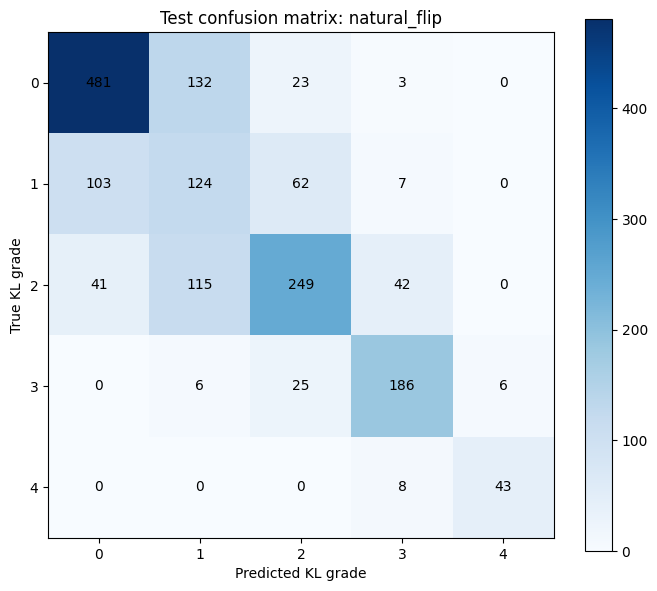

{
  "accuracy": 0.6539855072463768,
  "qwk": 0.8224187105007749,
  "macro_precision": 0.685150872598101,
  "macro_recall": 0.6811845050645091,
  "macro_f1": 0.6801236367338533,
  "grade1_recall": 0.4189189189189189,
  "macro_ap": 0.7312958338493474,
  "macro_auc": 0.8963636695587465,
  "selection_score": 0.7295151125007628,
  "loss": 0.7766287156205246
}
              precision    recall  f1-score   support

     Grade 0       0.77      0.75      0.76       639
     Grade 1       0.33      0.42      0.37       296
     Grade 2       0.69      0.56      0.62       447
     Grade 3       0.76      0.83      0.79       223
     Grade 4       0.88      0.84      0.86        51

    accuracy                           0.65      1656
   macro avg       0.69      0.68      0.68      1656
weighted avg       0.67      0.65      0.66      1656



In [ ]:
selected_spec = selected_result["arm"]
test_paths_indexed, test_labels, test_hashes = index_split(
    "test", train_hashes | validation_hashes
)
test_dataset = KneeDataset(
    test_paths_indexed,
    test_labels,
    evaluation_transform,
    selected_spec["canonicalize_laterality"],
)
test_loader = DataLoader(
    test_dataset,
    batch_size=48,
    shuffle=False,
    num_workers=4,
    pin_memory=device.type == "cuda",
    persistent_workers=True,
)

selected_model = DenseNet121NativeCAM(pretrained=False).to(device)
selected_checkpoint = load_checkpoint(selected_path)
selected_model.load_state_dict(selected_checkpoint["model_state_dict"])
selected_model.eval()
test_metrics, test_true, test_predicted, test_probabilities, test_paths = evaluate(
    selected_model, test_loader, "TEST SELECTED NON-CANONICAL ARM"
)

prediction_rows = []
for path, true_grade, predicted_grade, probabilities in zip(
    test_paths, test_true, test_predicted, test_probabilities
):
    prediction_rows.append({
        "path": path,
        "true_grade": int(true_grade),
        "predicted_grade": int(predicted_grade),
        **{
            f"grade_{grade}_probability": float(probabilities[grade])
            for grade in range(5)
        },
    })
with open(RUN_DIR / "selected_test_predictions.csv", "w", newline="") as handle:
    writer = csv.DictWriter(handle, fieldnames=prediction_rows[0].keys())
    writer.writeheader()
    writer.writerows(prediction_rows)
with open(RUN_DIR / "selected_test_metrics.json", "w") as handle:
    json.dump(test_metrics, handle, indent=2)

matrix = confusion_matrix(test_true, test_predicted, labels=[0, 1, 2, 3, 4])
figure, axis = plt.subplots(figsize=(7, 6))
image = axis.imshow(matrix, cmap="Blues")
for row in range(5):
    for column in range(5):
        axis.text(column, row, matrix[row, column], ha="center", va="center")
axis.set(
    title=f"Test confusion matrix: {selected_arm_name}",
    xlabel="Predicted KL grade",
    ylabel="True KL grade",
    xticks=range(5),
    yticks=range(5),
)
figure.colorbar(image, ax=axis)
figure.tight_layout()
figure.savefig(RUN_DIR / "selected_test_confusion_matrix.png", dpi=180)
plt.show()

print(json.dumps(test_metrics, indent=2))
print(classification_report(
    test_true,
    test_predicted,
    labels=[0, 1, 2, 3, 4],
    target_names=[f"Grade {grade}" for grade in range(5)],
    zero_division=0,
))


## Validation Comparison

Predictive metrics and CAM geometry are shown separately. The CAM joint band is a
coarse quantitative check, not expert lesion annotation; inspect each arm's saved
`native_cam_worst_cases.png` before promoting a checkpoint.


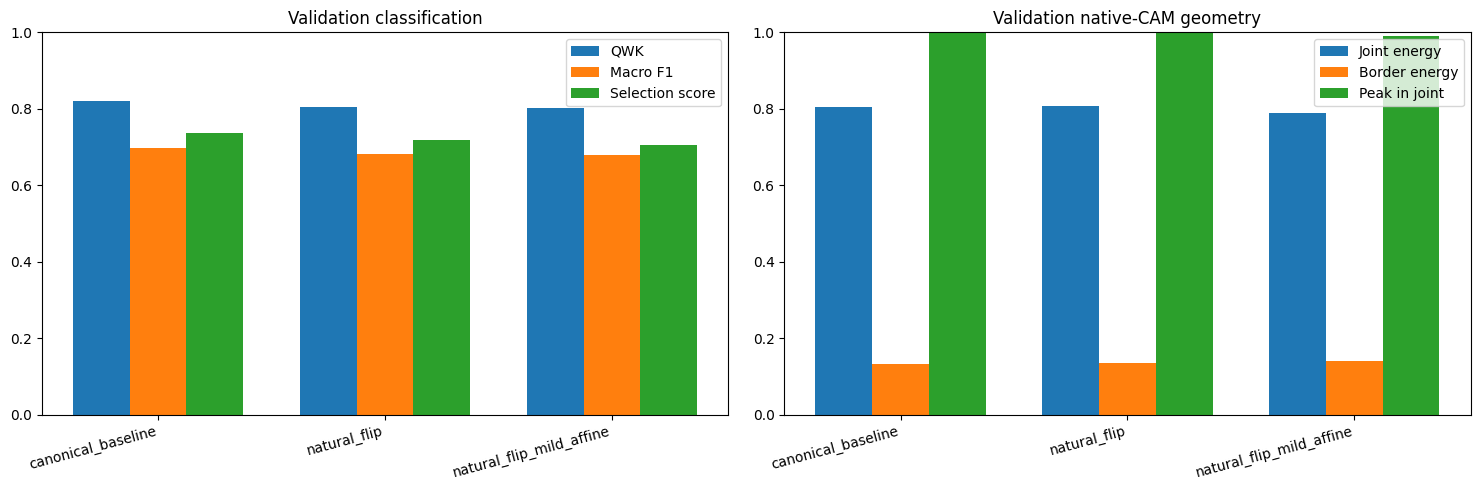

{
  "arm": "canonical_baseline",
  "canonicalize_laterality": true,
  "horizontal_flip_probability": 0.0,
  "augmentation": "current_mild_rotation",
  "best_epoch": 26,
  "qwk": 0.8195943029779887,
  "macro_f1": 0.697972416156584,
  "macro_recall": 0.707832033462769,
  "grade1_recall": 0.45751633986928103,
  "macro_ap": 0.7193215973961019,
  "macro_auc": 0.8881981299304839,
  "selection_score": 0.7362751878616567,
  "cam_joint_energy": 0.8057743978760221,
  "cam_border_energy": 0.13279094450205978,
  "cam_lower_tibia_energy": 0.09690862170822413,
  "cam_peak_inside_joint_rate": 1.0,
  "checkpoint": "/content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-25_00-34-38_777810_UTC_orientation_augmentation_ablation/canonical_baseline/best_model.pth"
}
{
  "arm": "natural_flip",
  "canonicalize_laterality": false,
  "horizontal_flip_probability": 0.5,
  "augmentation": "current_mild_rotation",
  "best_epoch": 30,
  "qwk": 0.8053026079415226,
  "macro_f1": 0.682007787980171,
  "macro_re

In [ ]:
comparison_rows = []
for name, result in arm_results.items():
    metrics = result["validation_metrics"]
    cam = result["native_cam_summary"]
    comparison_rows.append({
        "arm": name,
        "canonicalize_laterality": result["arm"]["canonicalize_laterality"],
        "horizontal_flip_probability": result["arm"]["horizontal_flip_probability"],
        "augmentation": result["arm"]["augmentation"],
        "best_epoch": result["best_epoch"],
        "qwk": metrics["qwk"],
        "macro_f1": metrics["macro_f1"],
        "macro_recall": metrics["macro_recall"],
        "grade1_recall": metrics["grade1_recall"],
        "macro_ap": metrics["macro_ap"],
        "macro_auc": metrics["macro_auc"],
        "selection_score": metrics["selection_score"],
        "cam_joint_energy": cam["joint_energy"],
        "cam_border_energy": cam["border_energy"],
        "cam_lower_tibia_energy": cam["lower_tibia_energy"],
        "cam_peak_inside_joint_rate": cam["peak_inside_joint_rate"],
        "checkpoint": result["checkpoint"],
    })

with open(RUN_DIR / "ablation_comparison.csv", "w", newline="") as handle:
    writer = csv.DictWriter(handle, fieldnames=comparison_rows[0].keys())
    writer.writeheader()
    writer.writerows(comparison_rows)
with open(RUN_DIR / "ablation_results.json", "w") as handle:
    json.dump(arm_results, handle, indent=2)

names = [row["arm"] for row in comparison_rows]
x = np.arange(len(names))
figure, axes = plt.subplots(1, 2, figsize=(15, 5))
width = 0.25
for offset, key, label in (
    (-width, "qwk", "QWK"),
    (0, "macro_f1", "Macro F1"),
    (width, "selection_score", "Selection score"),
):
    axes[0].bar(
        x + offset,
        [row[key] for row in comparison_rows],
        width,
        label=label,
    )
axes[0].set_xticks(x, names, rotation=15, ha="right")
axes[0].set_ylim(0, 1)
axes[0].set_title("Validation classification")
axes[0].legend()

for offset, key, label in (
    (-width, "cam_joint_energy", "Joint energy"),
    (0, "cam_border_energy", "Border energy"),
    (width, "cam_peak_inside_joint_rate", "Peak in joint"),
):
    axes[1].bar(
        x + offset,
        [row[key] for row in comparison_rows],
        width,
        label=label,
    )
axes[1].set_xticks(x, names, rotation=15, ha="right")
axes[1].set_ylim(0, 1)
axes[1].set_title("Validation native-CAM geometry")
axes[1].legend()
figure.tight_layout()
figure.savefig(RUN_DIR / "ablation_comparison.png", dpi=180)
plt.show()

for row in comparison_rows:
    print(json.dumps(row, indent=2))


## Reproducible Experiment Report

The report records the exact arm definitions, best validation epochs and metrics,
CAM audit, selected non-canonical checkpoint, and its single test evaluation.


In [ ]:
manifest = {
    "run_timestamp": RUN_TIMESTAMP,
    "run_directory": str(RUN_DIR),
    "experiment": "densenet121_orientation_augmentation_ablation",
    "paper_source": "docs/paper/fmed-12-1707588.md",
    "shared_config": {
        "architecture": "final_linear_native_cam",
        "loss": "cross_entropy",
        "input_resize": 400,
        "input_crop": 384,
        "batch_size": 48,
        "sampler": "full_inverse_frequency",
        "seed": 42,
        "stage_epochs": [5, 15, 10],
        "learning_rates": [3e-4, 3e-5, 1e-5],
    },
    "arms": arm_results,
    "overall_validation_winner": overall_validation_winner,
    "selected_noncanonical_arm": selected_arm_name,
    "selected_checkpoint": str(selected_path),
    "selected_test_metrics": test_metrics,
}
with open(RUN_DIR / "run_manifest.json", "w") as handle:
    json.dump(manifest, handle, indent=2)
(RUN_DIR / "SELECTED_NONCANONICAL_CHECKPOINT.txt").write_text(
    str(selected_path) + "\n"
)

table_rows = []
for row in comparison_rows:
    table_rows.append(
        f"| `{row['arm']}` | {row['qwk']:.4f} | {row['macro_f1']:.4f} | "
        f"{row['grade1_recall']:.4f} | {row['macro_ap']:.4f} | "
        f"{row['selection_score']:.4f} | {row['cam_joint_energy']:.4f} | "
        f"{row['cam_border_energy']:.4f} | "
        f"{row['cam_peak_inside_joint_rate']:.4f} |"
    )
result_table = "\n".join(table_rows)
report = f"""# DenseNet-121 Laterality and Augmentation Ablation

| Field | Value |
| --- | --- |
| Run timestamp | {RUN_TIMESTAMP} |
| Architecture | `final_linear_native_cam` |
| Loss | Cross-entropy |
| Split and seed | Fixed, seed 42 |
| Sampler | Full inverse-frequency |
| Overall validation winner | `{overall_validation_winner}` |
| Selected non-canonical arm | `{selected_arm_name}` |
| Selected checkpoint | `{selected_path}` |

## Validation and Native-CAM Comparison

| Arm | QWK | Macro F1 | Grade 1 recall | AP | Selection | Joint energy | Border energy | Peak in joint |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
{result_table}

## Selected Non-Canonical Test Result

| Accuracy | QWK | Macro F1 | Macro recall | Grade 1 recall | AP | AUC |
| ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| {test_metrics['accuracy']:.4f} | {test_metrics['qwk']:.4f} | {test_metrics['macro_f1']:.4f} | {test_metrics['macro_recall']:.4f} | {test_metrics['grade1_recall']:.4f} | {test_metrics['macro_ap']:.4f} | {test_metrics['macro_auc']:.4f} |

## Interpretation Rule

Prefer `natural_flip` when it matches or improves predictive metrics, because it
removes the inference-time laterality rule with the smallest training change. Use
`natural_flip_mild_affine` only when it improves validation QWK/macro F1 without
reducing joint energy or increasing border/lower-tibia energy materially. The CAM
masks are coarse anatomical proxies, so inspect each arm's worst-case montage.

The paper's augmentation magnitudes were not copied directly. Rotation, shift,
scale, and shear were constrained to protect subtle joint-space-narrowing geometry.
"""
(RUN_DIR / "report.md").write_text(report, encoding="utf-8")
print(f"Report: {RUN_DIR / 'report.md'}")
print(f"All artifacts: {RUN_DIR}")


Report: /content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-25_00-34-38_777810_UTC_orientation_augmentation_ablation/report.md
All artifacts: /content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-25_00-34-38_777810_UTC_orientation_augmentation_ablation


In [ ]:
try:
    from google.colab import runtime
    print("All artifacts saved. Releasing the Colab runtime.")
    runtime.unassign()
except ImportError:
    print("Not running in Colab; runtime release skipped.")


All artifacts saved. Releasing the Colab runtime.
